#EDA project1

In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
# import the data
df=pd.read_csv("TSLA.csv")

In [38]:
# show the data
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,6/29/2010,19.000000,25.000000,17.540001,23.889999,23.889999,18766300
1,6/30/2010,25.790001,30.420000,23.299999,23.830000,23.830000,17187100
2,7/1/2010,25.000000,25.920000,20.270000,21.959999,21.959999,8218800
3,7/2/2010,23.000000,23.100000,18.709999,19.200001,19.200001,5139800
4,7/6/2010,20.000000,20.000000,15.830000,16.110001,16.110001,6866900
...,...,...,...,...,...,...,...
2411,1/28/2020,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,1/29/2020,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,1/30/2020,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,1/31/2020,640.000000,653.000000,632.520020,650.570007,650.570007,15719300


In [40]:
df.columns
df.shape
#df.info

(2416, 7)

In [41]:
df.set_index('Date',inplace=True)
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
6/29/2010,19.000000,25.000000,17.540001,23.889999,23.889999,18766300
6/30/2010,25.790001,30.420000,23.299999,23.830000,23.830000,17187100
7/1/2010,25.000000,25.920000,20.270000,21.959999,21.959999,8218800
7/2/2010,23.000000,23.100000,18.709999,19.200001,19.200001,5139800
7/6/2010,20.000000,20.000000,15.830000,16.110001,16.110001,6866900
...,...,...,...,...,...,...
1/28/2020,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
1/29/2020,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
1/30/2020,632.419983,650.880005,618.000000,640.809998,640.809998,29005700


In [43]:
df.columns
df.sample(10)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
7/13/2017,330.109985,331.600006,319.970001,323.410004,323.410004,8594500
7/15/2019,248.000000,254.419998,244.860001,253.500000,253.500000,11000100
8/3/2011,27.500000,27.830000,26.340000,27.200001,27.200001,1794500
1/24/2012,26.629999,27.680000,26.440001,27.420000,27.420000,858000
6/15/2015,249.699997,251.279999,246.009995,250.380005,250.380005,2186200
7/13/2011,28.430000,29.030001,27.900000,28.639999,28.639999,1066000
1/30/2012,29.490000,29.610001,28.530001,29.570000,29.570000,729000
11/14/2017,315.000000,316.350006,306.899994,308.700012,308.700012,5676100
11/16/2017,313.989990,318.140015,311.299988,312.500000,312.500000,5822100


In [47]:
df.isnull().sum()


Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

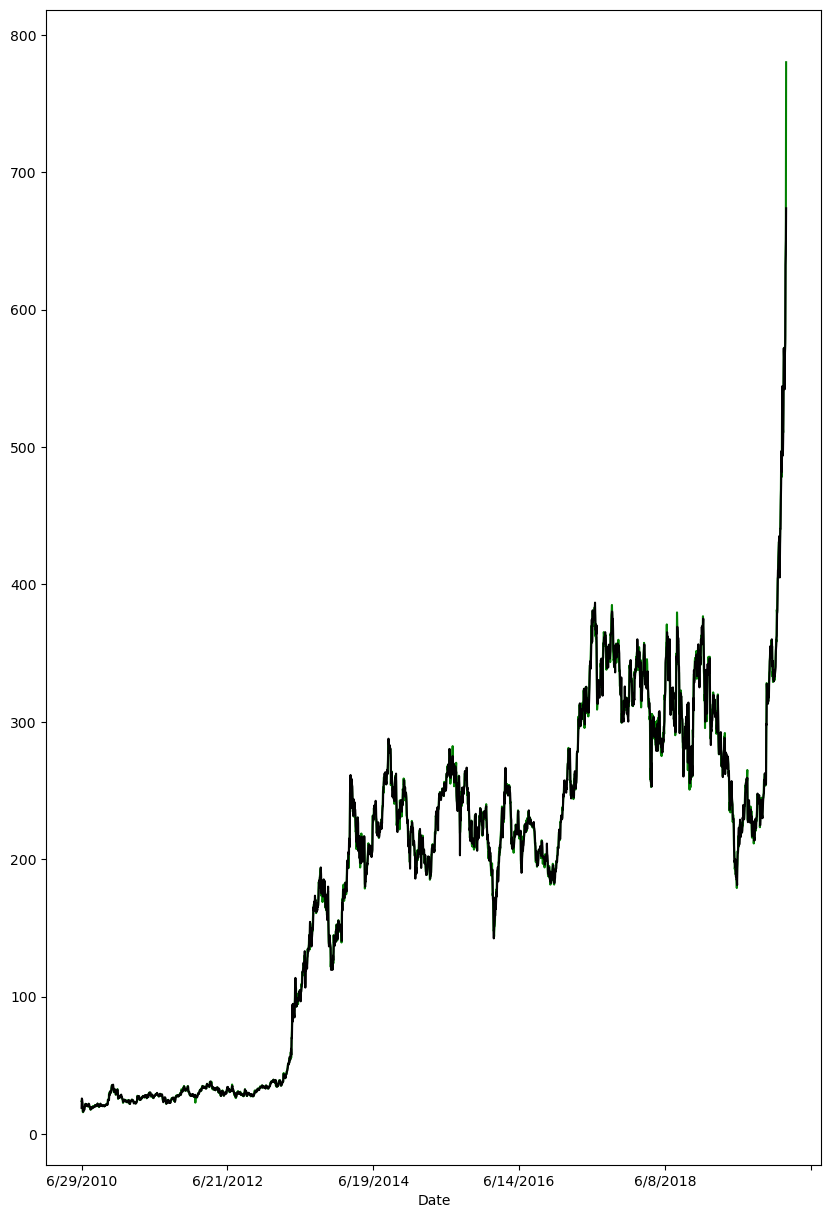

In [66]:
plt.figure(figsize=(10,15))
df['Close'].plot(color='green')
# plt.plot(df['Close'],color='green')
df['Open'].plot(color='Black')
plt.show()

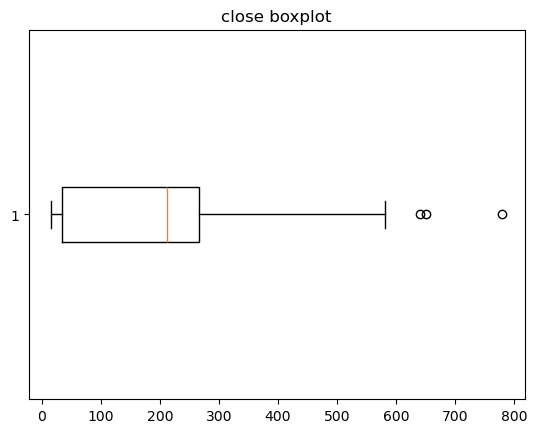

In [69]:
plt.boxplot(df['Close'],vert=False)
plt.title("close boxplot")
plt.show()

In [93]:
def detect_outliers_iqr(df,Close):
 Q1=df[Close].quantile(0.25)
 Q3=df[Close].quantile(0.75)
 IQR=Q3-Q1
 lower_bound=Q1-1.5*IQR
 upper_bound=Q3+1.5*IQR
 outliers=df[(df[Close]<lower_bound)| (df[Close]>upper_bound)]
 return outliers,Q1,Q3,lower_bound,upper_bound

outliers,Q1,Q3,lower_bound,upper_bound=detect_outliers_iqr(df,'Close')

print("Q1:",Q1)
print("Q3:",Q3)
print("lower_bound:",lower_bound)
print("upper_bound:",upper_bound)

print("Number of outliers detected:",len(outliers))
outliers

Q1: 34.400002
Q3: 266.774994
lower_bound: -314.16248599999994
upper_bound: 615.3374819999999
Number of outliers detected: 3


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1/30/2020,632.419983,650.880005,618.00000,640.809998,640.809998,29005700
1/31/2020,640.000000,653.000000,632.52002,650.570007,650.570007,15719300
2/3/2020,673.690002,786.140015,673.52002,780.000000,780.000000,47065000


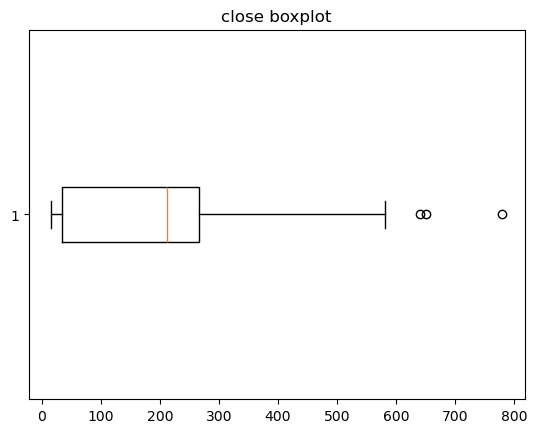

In [94]:
plt.boxplot(df['Close'],vert=False)
plt.title("close boxplot")
plt.show()

In [100]:
cleaned_data=df[np.logical_and((df['Close']>lower_bound),(df['Close']<upper_bound))]
print("outliers removed.original df.shape:",df.shape)
print("cleaned_data shape:",cleaned_data.shape)
# print("outliers detected:/n",outliers[['Close']])

outliers removed.original df.shape: (2416, 6)
cleaned_data shape: (2413, 6)


In [102]:
cleaned_data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
6/29/2010,19.000000,25.000000,17.540001,23.889999,23.889999,18766300
6/30/2010,25.790001,30.420000,23.299999,23.830000,23.830000,17187100
7/1/2010,25.000000,25.920000,20.270000,21.959999,21.959999,8218800
7/2/2010,23.000000,23.100000,18.709999,19.200001,19.200001,5139800
7/6/2010,20.000000,20.000000,15.830000,16.110001,16.110001,6866900
...,...,...,...,...,...,...
1/23/2020,564.250000,582.000000,555.599976,572.200012,572.200012,19651000
1/24/2020,570.630005,573.859985,554.260010,564.820007,564.820007,14353600
1/27/2020,541.989990,564.440002,539.280029,558.020020,558.020020,13608100


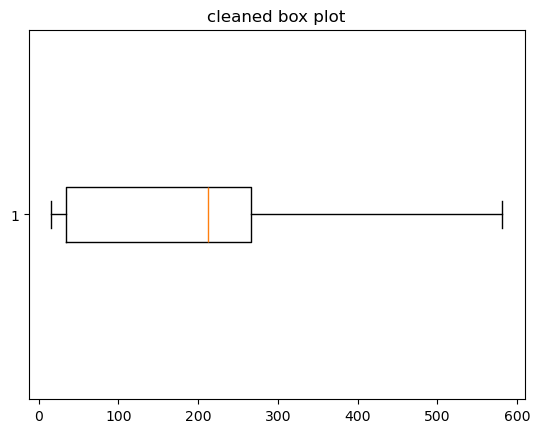

In [110]:
plt.boxplot(cleaned_data['Close'],vert=False)
plt.title("cleaned box plot")
plt.show()

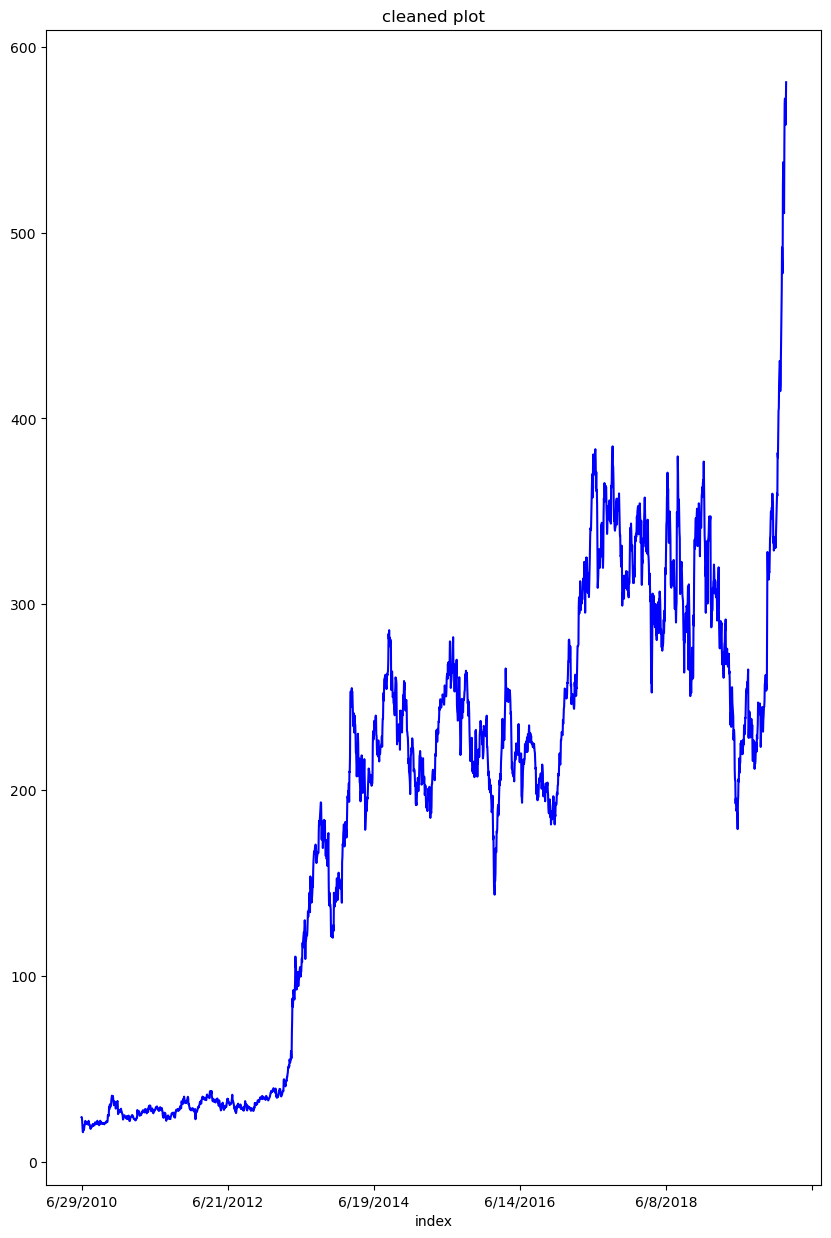

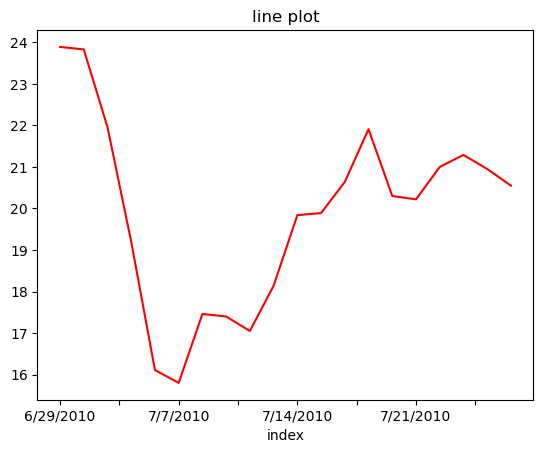

In [127]:
df_close=cleaned_data['Close']
plt.figure(figsize=(10,15))
df_close.plot(color='blue',markersize=3)
plt.xlabel('index')
plt.title("cleaned plot")
plt.show()
df_close=df_close[:20]
df_close.plot(color='red',markersize=3)
plt.xlabel("index")
plt.title("line plot")
plt.show()

In [129]:
print("original summary statistics:")
print(df['Close'].describe())
print("/ncleaned summary statistics:")
print(cleaned_data ['Close'].describe())
print()
print()
cleaned_data.describe()

original summary statistics:
count    2416.000000
mean      186.403651
std       119.136020
min        15.800000
25%        34.400002
50%       212.960007
75%       266.774994
max       780.000000
Name: Close, dtype: float64
/ncleaned summary statistics:
count    2413.000000
mean      185.776975
std       117.854296
min        15.800000
25%        34.400002
50%       212.940002
75%       266.380005
max       580.989990
Name: Close, dtype: float64




,Open,High,Low,Close,Adj Close,Volume
count,2413.000000,2413.000000,2413.000000,2413.000000,2413.000000,2.413000e+03
mean,185.696221,188.947770,182.346689,185.776975,185.776975,5.541610e+06
std,117.686266,119.615734,115.802755,117.854296,117.854296,4.891228e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.320000,34.889999,33.580002,34.400002,34.400002,1.893200e+06
50%,212.949997,216.720001,208.800003,212.940002,212.940002,4.573000e+06
75%,266.250000,270.500000,262.000000,266.380005,266.380005,7.352100e+06
max,575.690002,594.500000,567.429993,580.989990,580.989990,3.716390e+07


In [140]:
df.corr(method='pearson')

,Open,High,Low,Close,Adj Close,Volume
Open,1.000000,0.999425,0.999575,0.998886,0.998886,0.501762
High,0.999425,1.000000,0.999389,0.999640,0.999640,0.512944
Low,0.999575,0.999389,1.000000,0.999447,0.999447,0.493496
Close,0.998886,0.999640,0.999447,1.000000,1.000000,0.505169
Adj Close,0.998886,0.999640,0.999447,1.000000,1.000000,0.505169
Volume,0.501762,0.512944,0.493496,0.505169,0.505169,1.000000


<Axes: >

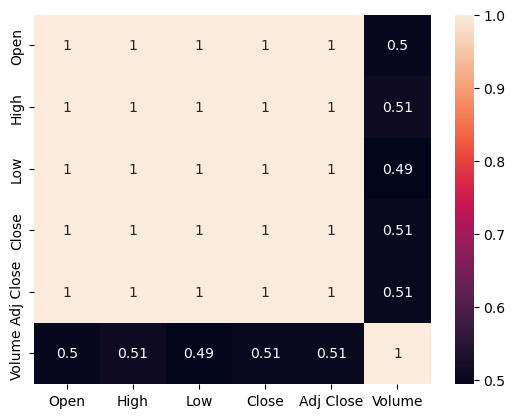

In [131]:
sns.heatmap(df.corr(),annot=True)

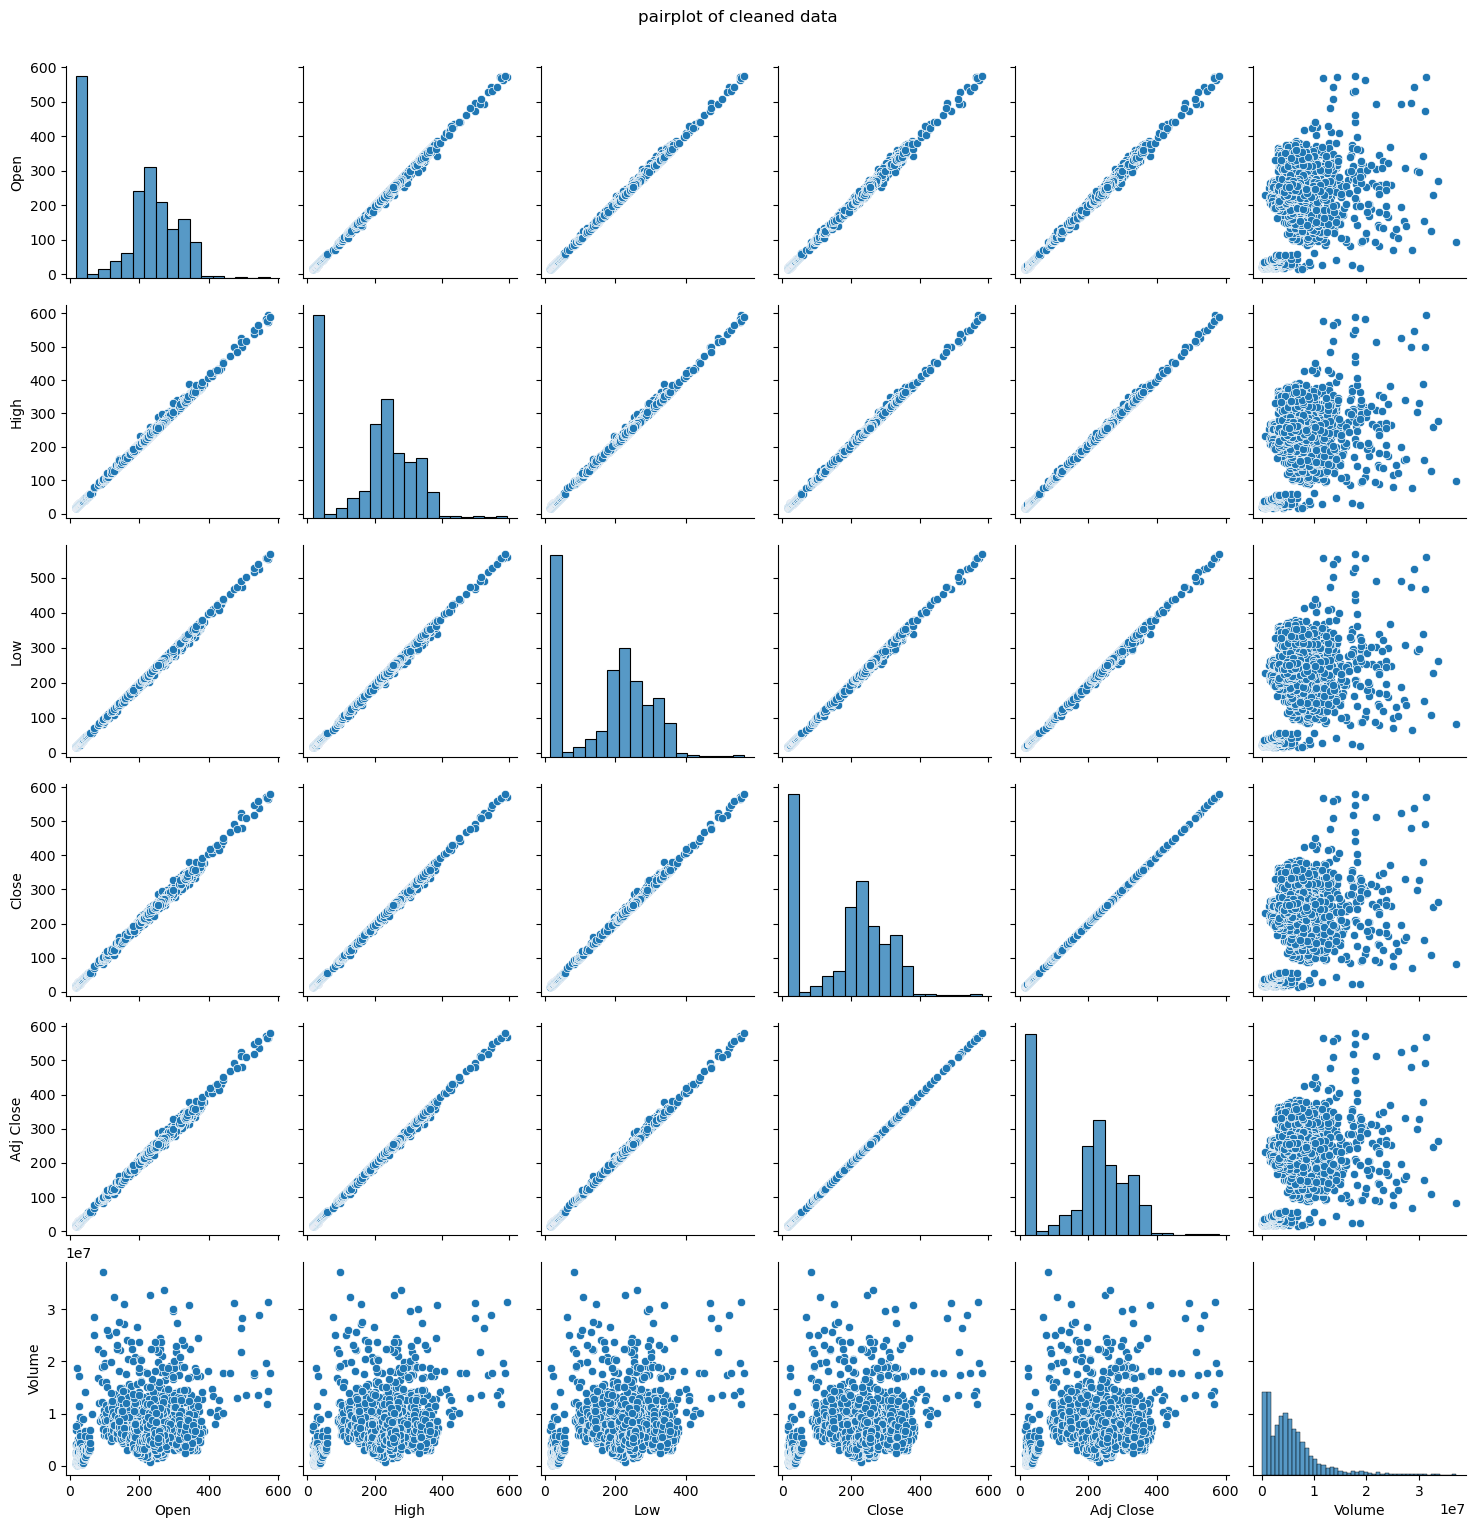

In [137]:
sns.pairplot(cleaned_data)
plt.suptitle('pairplot of cleaned data',y=1.02)
plt.show()

In [141]:
cleaned_data.tail(20)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
12/31/2019,405.000000,421.290009,402.079987,418.329987,418.329987,10285700
1/2/2020,424.500000,430.700012,421.709991,430.260010,430.260010,9532100
1/3/2020,440.500000,454.000000,436.920013,443.010010,443.010010,17778500
1/6/2020,440.470001,451.559998,440.000000,451.540009,451.540009,10133000
1/7/2020,461.399994,471.630005,453.359985,469.059998,469.059998,17882100
1/8/2020,473.700012,498.489990,468.230011,492.140015,492.140015,31144300
1/9/2020,497.100006,498.799988,472.869995,481.339996,481.339996,28440400
1/10/2020,481.790009,484.940002,473.700012,478.149994,478.149994,12959500
1/13/2020,493.500000,525.630005,492.000000,524.859985,524.859985,26517600


In [142]:
cleaned_data.head(10)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
6/29/2010,19.000000,25.000000,17.540001,23.889999,23.889999,18766300
6/30/2010,25.790001,30.420000,23.299999,23.830000,23.830000,17187100
7/1/2010,25.000000,25.920000,20.270000,21.959999,21.959999,8218800
7/2/2010,23.000000,23.100000,18.709999,19.200001,19.200001,5139800
7/6/2010,20.000000,20.000000,15.830000,16.110001,16.110001,6866900
7/7/2010,16.400000,16.629999,14.980000,15.800000,15.800000,6921700
7/8/2010,16.139999,17.520000,15.570000,17.459999,17.459999,7711400
7/9/2010,17.580000,17.900000,16.549999,17.400000,17.400000,4050600
7/12/2010,17.950001,18.070000,17.000000,17.049999,17.049999,2202500


In [149]:
cleaned_data['Daily return']=cleaned_data['Close'].pct_change()
cleaned_data

C:\Users\singh\AppData\Local\Temp\ipykernel_1156\1131269310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['Daily return']=cleaned_data['Close'].pct_change()


,Open,High,Low,Close,Adj Close,Volume,Daily return
Date,,,,,,,
6/29/2010,19.000000,25.000000,17.540001,23.889999,23.889999,18766300,NaN
6/30/2010,25.790001,30.420000,23.299999,23.830000,23.830000,17187100,-0.002511
7/1/2010,25.000000,25.920000,20.270000,21.959999,21.959999,8218800,-0.078473
7/2/2010,23.000000,23.100000,18.709999,19.200001,19.200001,5139800,-0.125683
7/6/2010,20.000000,20.000000,15.830000,16.110001,16.110001,6866900,-0.160937
...,...,...,...,...,...,...,...
1/23/2020,564.250000,582.000000,555.599976,572.200012,572.200012,19651000,0.004635
1/24/2020,570.630005,573.859985,554.260010,564.820007,564.820007,14353600,-0.012898
1/27/2020,541.989990,564.440002,539.280029,558.020020,558.020020,13608100,-0.012039


In [150]:
cleaned_data.isnull().sum()

Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Daily return    1
dtype: int64

In [155]:
cleaned_data['Daily return']=cleaned_data['Daily return'].fillna(0.0)


C:\Users\singh\AppData\Local\Temp\ipykernel_1156\2809027690.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_data['Daily return']=cleaned_data['Daily return'].fillna(0.0)


In [156]:
cleaned_data.to_csv("cleaned_tesla.csv")
print("cleaned data save to'cleaned_tesla.csv'.")

cleaned data save to'cleaned_tesla.csv'.


In [157]:
cleaned_data

,Open,High,Low,Close,Adj Close,Volume,Daily return
Date,,,,,,,
6/29/2010,19.000000,25.000000,17.540001,23.889999,23.889999,18766300,0.000000
6/30/2010,25.790001,30.420000,23.299999,23.830000,23.830000,17187100,-0.002511
7/1/2010,25.000000,25.920000,20.270000,21.959999,21.959999,8218800,-0.078473
7/2/2010,23.000000,23.100000,18.709999,19.200001,19.200001,5139800,-0.125683
7/6/2010,20.000000,20.000000,15.830000,16.110001,16.110001,6866900,-0.160937
...,...,...,...,...,...,...,...
1/23/2020,564.250000,582.000000,555.599976,572.200012,572.200012,19651000,0.004635
1/24/2020,570.630005,573.859985,554.260010,564.820007,564.820007,14353600,-0.012898
1/27/2020,541.989990,564.440002,539.280029,558.020020,558.020020,13608100,-0.012039
